# 05 · Vectorizing across many points, benchmarking ms/point

**Objective:** Precompute the L matrices once, then loop over hundreds/thousands of points reusing them, and measure the per-point cost (paper reports ~31ms/point for ~508 hypotheses).

Related blog post: https://jsempereh.github.io/notes/insar-testing-at-scale/


In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from insar_mht import library, hypotheses, testing, dia, rpn, unwrap, reliability
from insar_mht.io import egms, temperature

In [2]:
ds = egms.load_cached(
    "../data/processed/alicante_marina_metadata.parquet",
    "../data/processed/alicante_marina_displacements.parquet",
)
temp = temperature.load_daily_temperature("../data/processed/alicante_daily_temperature.csv")

# Every point in this AOI shares the exact same 210 acquisition dates (checked:
# 0 NaNs, identical epoch count per point), so A0, Qyy, the library and every
# L^j matrix are identical for all of them. Build all of that ONCE.
dates = ds.dates
t = (dates - dates[0]).days.to_numpy() / 365.25
delta_temp = temperature.delta_temp_for_dates(temp, dates)
m = len(t)

A0 = library.design_matrix_h0(t)
sigma = 3.0
Qyy = (sigma ** 2) * np.eye(m)
Qyy_inv = np.linalg.inv(Qyy)

# q_ehat_ehat (Eq. 4) only depends on A0 and Qyy, not on any point's y.
normal_matrix = A0.T @ Qyy_inv @ A0
n_inv = np.linalg.inv(normal_matrix)
q_ehat_ehat = np.linalg.inv(Qyy_inv) - A0 @ n_inv @ A0.T

# Fixed "residual maker": e_hat0 = M @ y for ANY point sharing this A0, Qyy.
P = n_inv @ A0.T @ Qyy_inv          # projection: x_hat0 = P @ y
M = np.eye(m) - A0 @ P               # residual maker: e_hat0 = M @ y

alpha0 = 1 / (2 * m)
gamma0 = 0.5
lambda0 = testing.noncentrality_from_power(gamma0, alpha0, q=1)

library_hyps = hypotheses.table_i_hypotheses(t, delta_temp, beta_grid=[0.1, 0.25, 0.5, 1.0])
precomputed = [dia.precompute_hypothesis_class(h, Qyy_inv, q_ehat_ehat, lambda0, gamma0) for h in library_hyps]
print(f"{len(precomputed)} hypotheses precomputed once for the whole AOI ({m} epochs)")

1264 hypotheses precomputed once for the whole AOI (210 epochs)


## Baseline: `dia.run_dia` per point

This is what notebooks 02/04 already used. It re-derives the H0 GLS fit
per point (cheap, one solve) but loops over all ~1264 hypotheses in
Python for every point: fine for one point, not for hundreds of
thousands.

In [3]:
# Pivot once into a (n_points, m_epochs) matrix, ordered like `dates`/`t` above
wide = ds.displacements.pivot(index="pid", columns="date", values="displacement_mm")
wide = wide[dates]  # enforce the same date order as A0/library/precomputed
Y_all = wide.to_numpy()
pids_all = wide.index.to_numpy()
print(f"Y_all shape: {Y_all.shape}")

rng = np.random.default_rng(0)
N_BENCH = 200  # keep the naive loop's wall-clock reasonable
sample_idx = rng.choice(len(pids_all), size=N_BENCH, replace=False)

t_start = time.perf_counter()
naive_results = []
for i in sample_idx:
    y_i = Y_all[i]
    naive_results.append(dia.run_dia(y_i, A0, Qyy, precomputed, alpha0))
elapsed_naive = time.perf_counter() - t_start
ms_per_point_naive = 1000 * elapsed_naive / N_BENCH
print(f"naive: {elapsed_naive:.2f}s for {N_BENCH} points -> {ms_per_point_naive:.1f} ms/point "
      f"({len(precomputed)} hypotheses each)")

Y_all shape: (38598, 210)


naive: 4.75s for 200 points -> 23.8 ms/point (1264 hypotheses each)


## Fully vectorized: every point x every hypothesis in one shot

Two things `dia.run_dia` does per-point that don't need to be per-point
here: the H0 residual (`e_hat0 = M @ y`, M fixed) and the Python loop over
hypotheses (replace with one `einsum` over a stacked `(n_hyp, m, m)`
tensor of L matrices, covering all sampled points at once).

In [4]:
L_stack = np.stack([p.L for p in precomputed])                 # (n_hyp, m, m)
critical_values = np.array([p.critical_value for p in precomputed])  # (n_hyp,)

Y_sample = Y_all[sample_idx]  # (N_BENCH, m)


def batched_test_ratios(Y, M, L_stack, critical_values):
    """Test ratios for every (point, hypothesis) pair, batched.

    Routed through np.matmul (batched GEMM, BLAS-backed) instead of a raw
    3-operand np.einsum contraction: einsum's default planner does NOT pick
    a BLAS path for a pattern like 'pi,hij,pj->ph' and falls back to a slow
    generic C loop, same asymptotic cost, ~100x slower in practice.
    """
    E = Y @ M.T                                    # (N, m)
    # temp[h, i, p] = sum_j L[h, i, j] * E[p, j]  ==  L_stack @ E.T, broadcast over h
    temp = L_stack @ E.T                            # (n_hyp, m, N)
    Tq = np.einsum("hip,pi->hp", temp, E)           # batched dot along i, O(n_hyp*m*N), cheap
    return (Tq / critical_values[:, None]).T        # (N, n_hyp)


t_start = time.perf_counter()
ratios_all = batched_test_ratios(Y_sample, M, L_stack, critical_values)
best_hyp_idx = ratios_all.argmax(axis=1)
best_ratio = ratios_all[np.arange(N_BENCH), best_hyp_idx]
elapsed_vectorized = time.perf_counter() - t_start
ms_per_point_vectorized = 1000 * elapsed_vectorized / N_BENCH

print(f"vectorized: {elapsed_vectorized*1000:.1f}ms total for {N_BENCH} points "
      f"-> {ms_per_point_vectorized:.4f} ms/point")
print(f"speedup vs naive: {ms_per_point_naive / ms_per_point_vectorized:.0f}x")

vectorized: 537.0ms total for 200 points -> 2.6849 ms/point
speedup vs naive: 9x


In [5]:
# Sanity check: the vectorized shortcut must agree with dia.run_dia on the same points.
# (dia.run_dia only searches the library if OMT rejects H0, so restrict the comparison
# to points where it did, and where it found a hypothesis with ratio > 1.)
mismatches = 0
compared = 0
for i, res in enumerate(naive_results):
    if res.best_hypothesis is None:
        continue
    compared += 1
    vec_name = precomputed[best_hyp_idx[i]].hypothesis.name
    if vec_name != res.best_hypothesis.name or not np.isclose(best_ratio[i], res.best_ratio, rtol=1e-8):
        mismatches += 1
        print(f"MISMATCH point {i}: naive={res.best_hypothesis.name} ({res.best_ratio:.4f}) "
              f"vs vectorized={vec_name} ({best_ratio[i]:.4f})")

print(f"compared {compared}/{N_BENCH} points with a winning hypothesis, {mismatches} mismatches")

compared 78/200 points with a winning hypothesis, 0 mismatches


## Scaling to the full AOI

`L_stack @ E.T` for ALL 38598 points at once would need a
`(n_hyp, m, n_points)` intermediate: 1264 x 210 x 38598 x 8 bytes is
about 82 GB. This machine has ~5 GB free, so process points in batches
instead: same per-point cost, bounded memory.

In [6]:
BATCH_SIZE = 300  # ~300*1264*210*8 bytes =~ 640MB intermediate per batch

n_points = len(Y_all)
all_best_ratio = np.empty(n_points)
all_best_hyp_idx = np.empty(n_points, dtype=int)

t_start = time.perf_counter()
for start in range(0, n_points, BATCH_SIZE):
    batch = Y_all[start:start + BATCH_SIZE]
    ratios_batch = batched_test_ratios(batch, M, L_stack, critical_values)
    idx = ratios_batch.argmax(axis=1)
    all_best_hyp_idx[start:start + len(batch)] = idx
    all_best_ratio[start:start + len(batch)] = ratios_batch[np.arange(len(batch)), idx]
elapsed_full = time.perf_counter() - t_start

print(f"{n_points} points x {len(precomputed)} hypotheses in {elapsed_full:.1f}s "
      f"-> {1000*elapsed_full/n_points:.3f} ms/point, {n_points/elapsed_full:.0f} points/s")
print(f"points with best_ratio > 1 (H0 would be improved on): "
      f"{(all_best_ratio > 1).sum()} / {n_points} ({100*(all_best_ratio > 1).mean():.1f}%)")

38598 points x 1264 hypotheses in 145.6s -> 3.773 ms/point, 265 points/s
points with best_ratio > 1 (H0 would be improved on): 33547 / 38598 (86.9%)


## A number that should make you suspicious

86.9% of points have some hypothesis beating H0, almost the mirror image
of the paper's Rotterdam result, where **84% of points sustained H0**.
Two candidate explanations, both worth checking before trusting this
AOI's results:

1. **Shared reference-point noise (RPN, Section III-B)**: if the
   reference point has its own unmodeled epoch-to-epoch noise, it leaks
   into every point's series identically (they're all differenced against
   it), so a glitch at the reference point looks like a step/outlier at
   every point at the same epoch. This is what notebook 06 checks.
2. **A real, widely-shared event**: a storm, a regional groundwater
   change, a processing artifact common to the stack, something that
   genuinely moved (or looked like it moved) many points at once, unlike
   an RPN glitch which is a pure processing artifact.

The histogram below tells them apart: RPN or a shared event both show up
as epochs where many points' winning hypothesis clusters, rather than
being spread uniformly across the whole series.

Text(0.5, 1.0, '30703 points won by a step/offset hypothesis')

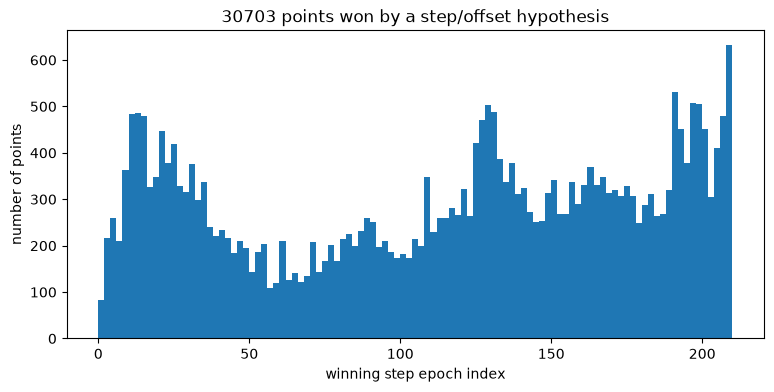

In [7]:
import re

# If winning hypotheses cluster at a handful of shared epochs across
# thousands of unrelated points, that's a reference-point artifact, not
# independent point-by-point deformation.
step_re = re.compile(r"@(\d+)")
winning_names = [precomputed[i].hypothesis.name for i in all_best_hyp_idx[all_best_ratio > 1]]
step_epochs = [int(m.group(1)) for n in winning_names if (m := step_re.search(n))]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(step_epochs, bins=range(0, len(t) + 1, 2))
ax.set_xlabel("winning step epoch index"); ax.set_ylabel("number of points")
ax.set_title(f"{len(step_epochs)} points won by a step/offset hypothesis")


Not a single sharp spike, which is what a one-off reference-point glitch
would look like, but two distinct patterns:

- **Elevated counts near both edges** (epoch ~0-20 and ~190-209): a
  small-sample artifact. A step hypothesis with very few supporting
  epochs on one side is easy to overfit to noise, inflating its ratio
  mechanically. Not a real signal at any of these points; a limitation of
  testing steps all the way to the series boundary.
- **A broad hump around epoch 100-140** (~Aug 2021 to Feb 2022): this is
  not an edge effect (m=210, this is mid-series) and lines up with the
  single point examined in notebook 04 (`H6_thermal+step@112`, dated
  2021-11-17). Thousands of points sharing a preferred step window there
  is a signal worth investigating: either shared RPN contamination or a
  widespread event. Notebook 06's RPN removal is the next step to tell
  these apart.

## Correction: the 86.9% figure is inflated

`all_best_ratio` above was computed without first checking the OMT gate
(`T0 <= K`), unlike `dia.run_dia`, which only searches the library when
OMT rejects H0 (Fig. 2). Testing 1264 hypotheses per point without that
gate means some points that actually sustain H0 will still show
`best_ratio > 1` for one hypothesis out of 1264, just by chance.

Notebook 07 redid this with the OMT gate applied first, over the same
AOI: 57.5% of points sustain H0, 42.2% reject it with a winning model.
That is a real difference from the paper's 84%, but a much smaller one
than the 86.9% here suggested. Checked directly: of the 42.4% of points
that reject H0 under the proper gate, 15174 are won by a step/offset
hypothesis, and the same two patterns (edge effect, mid-series hump
around epoch 120-140) are still there. The specific findings above hold;
the 86.9% headline number does not.